In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
df = pd.read_csv("imdb_dataset.csv")

In [ ]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)  #UPDATE: Remove HTML <br> tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
df['cleaned_reviews'] = df['review'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df.head()

,review,sentiment,cleaned_reviews
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [ ]:
analyzer = SentimentIntensityAnalyzer()
def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    return 'positive' if score['compound'] > 0 else 'negative' if score['compound'] < 0 else 'neutral'

df['sentiment'] = df['cleaned_reviews'].apply(get_sentiment)

In [ ]:
df.head()

,review,sentiment,cleaned_reviews
0,One of the other reviewers has mentioned that ...,negative,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [ ]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_reviews'])
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
def display_topics(model, feature_names, num_words):
    topics = {}
    topic_descriptions = []
    for topic_idx, topic in enumerate(model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
        topics[f"Topic {topic_idx}"] = words
        description = f"Topic {topic_idx}: {', '.join(words)}"
        topic_descriptions.append(description)
    return topics, topic_descriptions

topics, topic_descriptions = display_topics(lda, vectorizer.get_feature_names_out(), 10)

In [ ]:
print("\nExtracted Topics:")
for desc in topic_descriptions:
    print(f"- {desc}")


Extracted Topics:
- Topic 0: movie, film, like, bad, good, scene, make, time, really, acting
- Topic 1: movie, like, film, good, time, really, great, character, think, watch
- Topic 2: like, movie, time, film, episode, series, good, scene, character, thing
- Topic 3: film, role, performance, play, scene, character, best, man, good, time
- Topic 4: film, story, life, movie, character, time, people, world, way, war


<ipython-input-27-a9bbd0a57e07>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['sentiment'], palette='viridis')


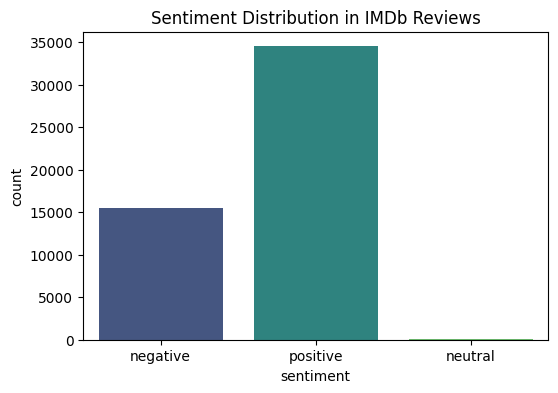

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['sentiment'], palette='viridis')
plt.title("Sentiment Distribution in IMDb Reviews")
plt.show()

In [ ]:
df.head()

,review,sentiment,cleaned_reviews
0,One of the other reviewers has mentioned that ...,negative,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [ ]:
df.head()

,review,sentiment,cleaned_reviews
0,One of the other reviewers has mentioned that ...,negative,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
def analyze_sentiment(review):
    sentiment_score = analyzer.polarity_scores(review)
    return sentiment_score['compound']

# Apply sentiment analysis to the cleaned reviews
df['predicted_sentiment'] = df['cleaned_reviews'].apply(analyze_sentiment)

# Convert compound score into a sentiment label (positive, negative, neutral)
df['predicted_sentiment_label'] = df['predicted_sentiment'].apply(lambda x: 'positive' if x > 0 else 'negative' if x < 0 else 'neutral')

print(df[['cleaned_reviews', 'predicted_sentiment', 'predicted_sentiment_label']])

                                         cleaned_reviews  predicted_sentiment  \
0      one reviewer mentioned watching oz episode you...              -0.9941   
1      wonderful little production filming technique ...               0.9571   
2      thought wonderful way spend time hot summer we...               0.9688   
3      basically there family little boy jake think t...              -0.9061   
4      petter matteis love time money visually stunni...               0.9887   
...                                                  ...                  ...   
49995  thought movie right good job wasnt creative or...               0.9614   
49996  bad plot bad dialogue bad acting idiotic direc...              -0.8555   
49997  catholic taught parochial elementary school nu...              -0.7615   
49998  im going disagree previous comment side maltin...              -0.6597   
49999  one expects star trek movie high art fan expec...               0.8307   

      predicted_sentiment_l

In [ ]:
# Assuming you have actual sentiment labels in 'sentiment'
accuracy = accuracy_score(df['sentiment'], df['predicted_sentiment_label'])
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 1.0000


In [ ]:
precision = precision_score(df['sentiment'], df['predicted_sentiment_label'], average='macro')
recall = recall_score(df['sentiment'], df['predicted_sentiment_label'], average='macro')
f1 = f1_score(df['sentiment'], df['predicted_sentiment_label'], average='macro')

# Print precision, recall, and f1-score
print(f'Precision (Macro): {precision:.4f}')
print(f'Recall (Macro): {recall:.4f}')
print(f'F1-Score (Macro): {f1:.4f}')

Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1-Score (Macro): 1.0000
